<h1>Stock Market Prediction Using Machine Learning and Ensemble Learning

<h2>Imports

In [868]:
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt



from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme()

<h2>Data Processing


In [869]:
# Ticker = input(print('Enter Ticker: '))
Ticker ='AAPL'

df = yf.download(Ticker,'2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [870]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200
...,...,...,...,...,...
2026-05-07,287.175415,291.861100,285.516939,289.003717,45224300
2026-05-08,293.050018,294.488695,289.733067,289.743067,52692800


In [871]:
df['Target'] = df['Close'].shift(-1)
df

Price,Close,High,Low,Open,Volume,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400,71.630638
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800,72.201416
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,71.861847
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,73.017845
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200,74.568787
...,...,...,...,...,...,...
2026-05-07,287.175415,291.861100,285.516939,289.003717,45224300,293.050018
2026-05-08,293.050018,294.488695,289.733067,289.743067,52692800,292.679993


In [872]:

df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()


df['Volatility'] = df['Close'].rolling(10).std()


df['Daily_Return'] = df['Close'].pct_change()

In [873]:
df.dropna(axis=0,inplace=True)

In [874]:
df.describe()

Price,Close,High,Low,Open,Volume,Target,MA_10,MA_50,Volatility,Daily_Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
count,1549.000000,1549.000000,1549.000000,1549.000000,1.549000e+03,1549.000000,1549.000000,1549.000000,1549.000000,1549.000000
mean,173.243755,175.010495,171.313216,173.088207,7.956446e+07,173.392759,172.598189,170.129532,3.642627,0.001213
std,51.339850,51.679368,50.962219,51.294573,4.659322e+07,51.366527,51.122725,50.679929,2.087379,0.019248
min,54.163708,55.160705,51.324804,55.059316,1.791060e+07,54.163708,58.871317,65.185128,0.578255,-0.128647
25%,138.534332,140.288985,136.031736,138.524509,4.882250e+07,138.587875,138.884033,137.878433,2.207171,-0.008023
50%,168.504852,170.245709,167.143478,168.378201,6.678130e+07,168.557449,168.464464,164.741745,3.145642,0.001140
75%,212.198792,214.088803,209.747897,211.590578,9.421490e+07,212.261292,210.542188,207.908008,4.595170,0.011025
max,294.799988,295.269989,292.559998,292.559998,4.016932e+08,297.910004,283.634808,272.495204,19.875915,0.153288


In [875]:
df.isnull().sum()


Price         Ticker
Close         AAPL      0
High          AAPL      0
Low           AAPL      0
Open          AAPL      0
Volume        AAPL      0
Target                  0
MA_10                   0
MA_50                   0
Volatility              0
Daily_Return            0
dtype: int64

<h2>Variables

In [876]:
target = df[['Target']]
features = df[['Close','Volume','High','Low','Open',
         'MA_10','MA_50',
         'Volatility','Daily_Return']]

<h2>Standardization


In [877]:
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(target)


In [878]:
scaler_x = StandardScaler()
x_scaled = scaler_x.fit_transform(features)

<h3>Train_Test

In [879]:
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y_scaled,test_size = 0.2,shuffle = False)

<h2>Model-1 Regression

In [880]:
model = LinearRegression()

In [881]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [882]:
R_Squared = model.score(x_train, y_train)
Bias = model.intercept_[0]


summary = pd.DataFrame({
    'Feature': ['R-Squared', 'Bias (Intercept)'],
    'Value': [R_Squared, Bias]
})

summary

,Feature,Value
0,R-Squared,0.995722
1,Bias (Intercept),-0.001068


In [883]:
y_pred = model.predict(x_test)

y_act = scaler_y.inverse_transform(y_pred)

y_test_act = scaler_y.inverse_transform(y_test)

<h2>Model 2 Random Forest

In [884]:
y_rf = df['Target']

<h3>Train_Test

In [885]:
x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(x_scaled,y_rf,test_size=0.2,shuffle=False)

In [886]:
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42
)

rf.fit(x_train_rf,y_train_rf)

rf_pred = rf.predict(x_test_rf)

<h2>Ensemble Learning

In [887]:
ensemble_pred = (0.8 * y_pred +0.2 * rf_pred.reshape(-1,1))

<h3> Error Calculation

In [888]:
comparison = pd.DataFrame({'Actual': y_test_act.flatten(),'Linear Regression': y_act.flatten(),'Random Forest': rf_pred.flatten()})

comparison['Ensemble'] = 0.8 * comparison['Linear Regression'] + 0.2 * comparison['Random Forest']

comparison['LR_Error'] = comparison['Actual'] - comparison['Linear Regression']
comparison['RF_Error'] = comparison['Actual'] - comparison['Random Forest']
comparison['Ensemble_Error'] = comparison['Actual'] - comparison['Ensemble']

comparison['LR_Smooth_Error'] = comparison['LR_Error'].rolling(10).mean()
comparison['RF_Smooth_Error'] = comparison['RF_Error'].rolling(10).mean()
comparison['Ensemble_Smooth_Error'] = comparison['Ensemble_Error'].rolling(10).mean()

In [889]:
comparison['Date'] = df.index[-len(comparison):]

lr_rmse = np.sqrt(mean_squared_error(comparison['Actual'], comparison['Linear Regression']))
lr_mae = mean_absolute_error(comparison['Actual'], comparison['Linear Regression'])

rf_rmse = np.sqrt(mean_squared_error(comparison['Actual'], comparison['Random Forest']))
rf_mae = mean_absolute_error(comparison['Actual'], comparison['Random Forest'])

ensemble_rmse = np.sqrt(mean_squared_error(comparison['Actual'], comparison['Ensemble']))
ensemble_mae = mean_absolute_error(comparison['Actual'], comparison['Ensemble'])

In [890]:
metrics = pd.DataFrame({'Model':['Linear Regression','Random Forest','Ensemble'],'RMSE':[lr_rmse,rf_rmse,ensemble_rmse],'MAE':[lr_mae,rf_mae,ensemble_mae]})

In [891]:
metrics

,Model,RMSE,MAE
0,Linear Regression,4.391970,2.953055
1,Random Forest,12.823321,9.206400
2,Ensemble,5.023885,3.620232


In [892]:
direction_acc = np.mean(np.sign(comparison['Actual'].diff()[1:]) == np.sign(comparison['Ensemble'].diff()[1:])) * 100

print(f'Direction Accuracy: {direction_acc:.2f}%')

Direction Accuracy: 52.75%


<h2>Chart

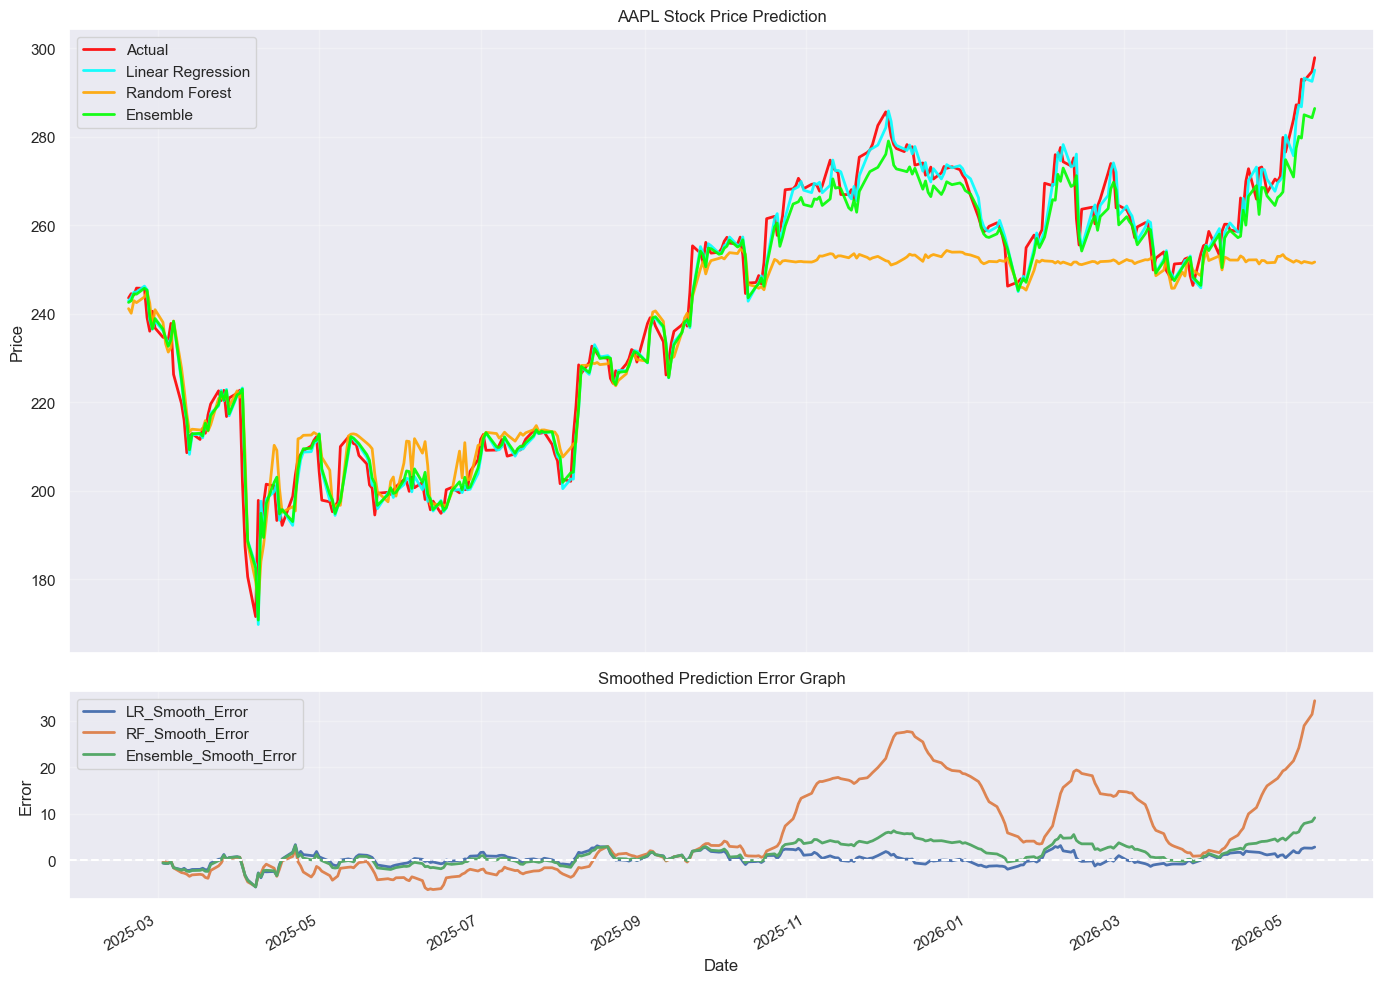

In [893]:
fig, axes = plt.subplots(2,1,figsize=(14,10),sharex=True,gridspec_kw={'height_ratios':[3,1]})

comparison.plot(x='Date',y=['Actual','Linear Regression','Random Forest','Ensemble'],ax=axes[0],linewidth=2,alpha=0.9,color=['red','cyan','orange','lime'],title=f'{Ticker} Stock Price Prediction')

axes[0].set_ylabel('Price')
axes[0].grid(alpha=0.3)


comparison.plot(x='Date',y=['LR_Smooth_Error','RF_Smooth_Error','Ensemble_Smooth_Error'],ax=axes[1],linewidth=2,title='Smoothed Prediction Error Graph')
axes[1].axhline(y=0,linestyle='--')
axes[1].set_ylabel('Error')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()